### Data preparation and preprocessing

In [43]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA

#load dataset
df = pd.read_csv('Shopping Mall Customer Segmentation Data .csv')

#preview before cleaning
print("\nTop 5 rows before preprocessing:")
print(df.head())

#----------------
# Data Cleaning
#----------------
# check for duplicate customer IDs
id_duplicates = df.duplicated(subset='Customer ID').sum()
print(f"Duplicate Customer IDs: {id_duplicates}")
if id_duplicates > 0:
    df = df.drop_duplicates(subset='Customer ID')
    print("\nDuplicate Customer IDs removed.")
else:
    print("No duplicate Customer IDs forund.")
    
# check and remove any duplicate rows
duplicate = df.duplicated().sum()
print(f"\nFull duplicate rows: {duplicate}")
if duplicate > 0:
    df = df.drop_duplicates()
    print("\nDuplicate rows is removed.")
else:
    print("\nNo duplicated rows found.")

# check annd fill missing values
missing = df.isnull().sum()
if missing.any():
    print("\nMissing values:", missing[missing > 0])
    df = df.fillna(method='ffill')
    print("\nMissing values handled with forward fill.")
else: 
    print("No missing values found.")

# normalize Gender column
df['Gender'] = df['Gender'].str.strip().str.title()
print("\nGender values normalized.")

# Remove any outliers
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} Outliers detected: {len(outliers)}")
    return df[(df[col] >= lower) & (df[col] <= upper)]

for column in ['Age', 'Annual Income', 'Spending Score']:
    df = remove_outliers(df, column)
print("Outliers removed from Age, Annual Income, and Spending Score.")

#preview after cleaning
print("\nTop 5 rows after cleaning")
print(df.head())


Top 5 rows before preprocessing:
                            Customer ID  Age  Gender  Annual Income  \
0  d410ea53-6661-42a9-ad3a-f554b05fd2a7   30    Male         151479   
1  1770b26f-493f-46b6-837f-4237fb5a314e   58  Female         185088   
2  e81aa8eb-1767-4b77-87ce-1620dc732c5e   62  Female          70912   
3  9795712a-ad19-47bf-8886-4f997d6046e3   23    Male          55460   
4  64139426-2226-4cd6-bf09-91bce4b4db5e   24    Male         153752   

   Spending Score  
0              89  
1              95  
2              76  
3              57  
4              76  
Duplicate Customer IDs: 0
No duplicate Customer IDs forund.

Full duplicate rows: 0

No duplicated rows found.
No missing values found.

Gender values normalized.
Age Outliers detected: 0
Annual Income Outliers detected: 0
Spending Score Outliers detected: 0
Outliers removed from Age, Annual Income, and Spending Score.

Top 5 rows after cleaning
                            Customer ID  Age  Gender  Annual Income  \


In [25]:
#--------------------
# Data integration
#--------------------

#prevent division by zero
df['Age'].replace(0, np.nan, inplace=True)
df['Age'].fillna(method='ffill', inplace=True)

#create Income_per_Age column
df['Income_per_Age'] = df['Annual Income'] / df['Age']
print("\n Added derived feature: Income_per_Age.")

#clean up any infinity or NaN just in case
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

#--------------------
# Data transformation
#---------------------

#normalize the numeric columns
scaler = MinMaxScaler()
cols_to_scale = ['Age', 'Annual Income', 'Spending Score', 'Income_per_Age']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
print("\nScale numerical columns using Min-Max normalization.")

# encode gender column
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
print("\nEncoded gender (Female=0, Male=1).")

#preview after scaling and encoding
print("\nTop 5 rows after scaling & encoding:")
print(df.head())


 Added derived feature: Income_per_Age.

Scale numerical columns using Min-Max normalization.

Encoded gender (Female=0, Male=1).

Top 5 rows after scaling & encoding:
                            Customer ID       Age  Gender  Annual Income  \
0  d410ea53-6661-42a9-ad3a-f554b05fd2a7  0.154930       1       0.730511   
1  1770b26f-493f-46b6-837f-4237fb5a314e  0.549296       0       0.917278   
2  e81aa8eb-1767-4b77-87ce-1620dc732c5e  0.605634       0       0.282798   
3  9795712a-ad19-47bf-8886-4f997d6046e3  0.056338       1       0.196930   
4  64139426-2226-4cd6-bf09-91bce4b4db5e  0.070423       1       0.743143   

   Spending Score  Income_per_Age  
0        0.888889        0.061316  
1        0.949495        0.023098  
2        0.757576        0.006474  
3        0.565657        0.039671  
4        0.757576        0.124753  


C:\Users\Nabila\AppData\Local\Temp\ipykernel_6664\4052660256.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].replace(0, np.nan, inplace=True)
C:\Users\Nabila\AppData\Local\Temp\ipykernel_6664\4052660256.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

In [29]:
#---------------
# Data Reduction
#----------------

#drop customer ID
df_reduced = df.drop(columns=['Customer ID'])

#apply PCA to reduce dimensionality
pca = PCA(n_components=2)
df_numeric = df_reduced.select_dtypes(include=[np.number])
pca_result = pca.fit_transform(df_numeric)
df_pca = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
print("\nPCA applied. Reduced to 2 principal components.")

#preview PCA result
print("\nPCA result (first 5 rows):")
print(df_pca.head())


PCA applied. Reduced to 2 principal components.

PCA result (first 5 rows):
        PC1       PC2
0  0.496427 -0.439783
1 -0.501966 -0.075781
2 -0.501073  0.061263
3  0.495653 -0.428582
4  0.495101 -0.501249



Discretization Age and Spending Score into 4 bins each.

Top 5 rows after preprocessing:
   Age      Age_bin  Spending Score  Score_bin
0   30        Young              89  Very High
1   58  Middle-aged              95  Very High
2   62  Middle-aged              76  Very High
3   23        Young              57       High
4   24        Young              76  Very High
Exported cleaned data to 'cleaned_customer_data.csv'
Exported PCA data to 'pca_customer_data.csv'


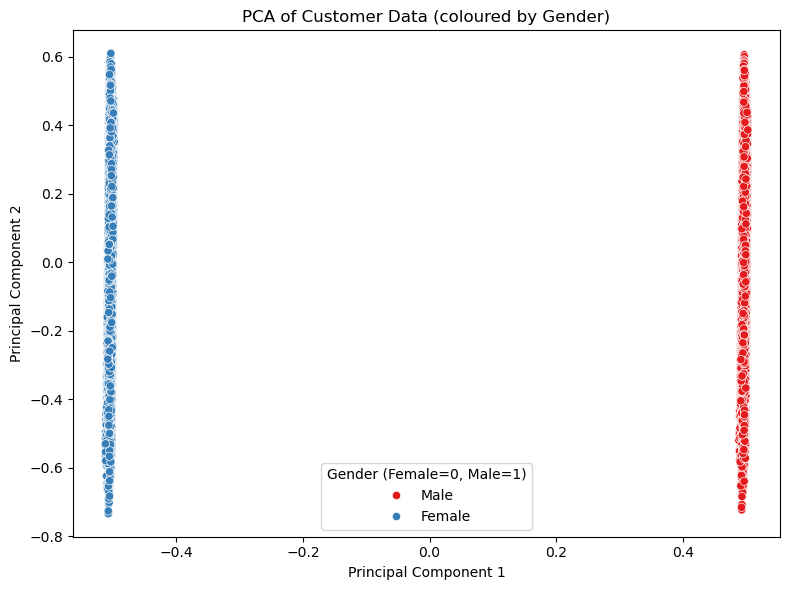

In [45]:
#--------------------
# Data Discretization
#---------------------

df['Age_bin'] = pd.cut(df['Age'], bins=4, labels=["Young", "Adult", "Middle-aged", "Senior"])
df['Score_bin'] = pd.cut(df['Spending Score'], bins=4, labels=["Low", "Medium", "High", "Very High"])
print("\nDiscretization Age and Spending Score into 4 bins each.")

#preview after discretization
print("\nTop 5 rows after preprocessing:")
print(df[['Age', 'Age_bin', 'Spending Score', 'Score_bin']].head())

#--------------------
# Export cleaned data
#---------------------
df.to_csv("cleaned_customer_data.csv", index=False)
df_pca.to_csv("pca_customer_data.csv", index=False)
print("Exported cleaned data to 'cleaned_customer_data.csv'")
print("Exported PCA data to 'pca_customer_data.csv'")

#---------------------
# PCA visualization
#---------------------
plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', data=df_pca, hue=df['Gender'], palette='Set1')
plt.title("PCA of Customer Data (coloured by Gender)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title='Gender (Female=0, Male=1)')
plt.tight_layout()
plt.show()